# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: xx

Group Members:
- Name (NIM)
- Name (NIM)
- ...

## Import Libraries

In [350]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 67

## Import Dataset

In [351]:
df = pd.read_csv("../data/train.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: 3096 rows x 38 columns

Columns: ['Student_ID', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [352]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Previous qualification', 'Nationality', 
    "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation", 'Educational special needs', 
    'International', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 
    'Displaced', 'Gender'
]

continuous_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Continuous columns: {len(continuous_cols)}")
print(f"Total: {len(categorical_cols) + len(continuous_cols)}")

Categorical columns: 17
Continuous columns: 18
Total: 35


# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [353]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nValidation target distribution:")
print(y_val.value_counts())

Training set: 2476 samples
Validation set: 620 samples

Training target distribution:
Target
Graduate    1236
Dropout      795
Enrolled     445
Name: count, dtype: int64

Validation target distribution:
Target
Graduate    310
Dropout     199
Enrolled    111
Name: count, dtype: int64


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [354]:
print("Missing values in training set:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_num = SimpleImputer(strategy='median')

X_train_clean = X_train.copy()
X_val_clean = X_val.copy()

if len(categorical_cols) > 0:
    existing_cat_cols = [col for col in categorical_cols if col in X_train_clean.columns]
    X_train_clean[existing_cat_cols] = imputer_cat.fit_transform(X_train_clean[existing_cat_cols])
    X_val_clean[existing_cat_cols] = imputer_cat.transform(X_val_clean[existing_cat_cols])

if len(continuous_cols) > 0:
    existing_cont_cols = [col for col in continuous_cols if col in X_train_clean.columns]
    X_train_clean[existing_cont_cols] = imputer_num.fit_transform(X_train_clean[existing_cont_cols])
    X_val_clean[existing_cont_cols] = imputer_num.transform(X_val_clean[existing_cont_cols])

print(f"\nMissing values after imputation:")
print(f"Training: {X_train_clean.isnull().sum().sum()}")
print(f"Validation: {X_val_clean.isnull().sum().sum()}")

Missing values in training set:
Series([], dtype: int64)

Missing values after imputation:
Training: 0
Validation: 0


**Explanation:** SimpleImputer digunakan untuk mengisi missing values. Categorical columns diisi dengan nilai yang paling sering muncul (most_frequent), sedangkan continuous columns diisi dengan median untuk mengurangi pengaruh outliers.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [355]:
print("Skipping outlier handling for Decision Tree model")

Skipping outlier handling for Decision Tree model


### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [356]:
duplicates_train = X_train_clean.duplicated().sum()
duplicates_val = X_val_clean.duplicated().sum()

print(f"Duplicates in training: {duplicates_train}")
print(f"Duplicates in validation: {duplicates_val}")

X_train_clean = X_train_clean.drop_duplicates()
X_val_clean = X_val_clean.drop_duplicates()

y_train = y_train[X_train_clean.index]
y_val = y_val[X_val_clean.index]

print(f"\nAfter removing duplicates:")
print(f"Training set: {X_train_clean.shape[0]} samples")
print(f"Validation set: {X_val_clean.shape[0]} samples")

Duplicates in training: 0
Duplicates in validation: 0

After removing duplicates:
Training set: 2476 samples
Validation set: 620 samples


**Explanation:** Duplicate rows dihapus untuk menghindari bias dalam training. Data yang sama persis dapat menyebabkan model overfitting pada pola tertentu.

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [357]:
X_train_fe = X_train_clean.copy()
X_val_fe = X_val_clean.copy()

# ============================================================================
# BASIC FEATURES (Total Units)
# ============================================================================

# FE1: TotalApproval
# Formula: Curricular units 1st sem (approved) + Curricular units 2nd sem (approved)
X_train_fe['TotalApproval'] = X_train_fe['Curricular units 1st sem (approved)'] + X_train_fe['Curricular units 2nd sem (approved)']
X_val_fe['TotalApproval'] = X_val_fe['Curricular units 1st sem (approved)'] + X_val_fe['Curricular units 2nd sem (approved)']

# FE2: TotalEnrolled
# Formula: Curricular units 1st sem (enrolled) + Curricular units 2nd sem (enrolled)
X_train_fe['TotalEnrolled'] = X_train_fe['Curricular units 1st sem (enrolled)'] + X_train_fe['Curricular units 2nd sem (enrolled)']
X_val_fe['TotalEnrolled'] = X_val_fe['Curricular units 1st sem (enrolled)'] + X_val_fe['Curricular units 2nd sem (enrolled)']

# FE3: TotalEvaluation
# Formula: Curricular units 1st sem (evaluations) + Curricular units 2nd sem (evaluations)
X_train_fe['TotalEvaluation'] = X_train_fe['Curricular units 1st sem (evaluations)'] + X_train_fe['Curricular units 2nd sem (evaluations)']
X_val_fe['TotalEvaluation'] = X_val_fe['Curricular units 1st sem (evaluations)'] + X_val_fe['Curricular units 2nd sem (evaluations)']

# ============================================================================
# APPROVAL METRICS
# ============================================================================

# FE4: ApprovalRate (rasio kelulusan)
# Formula: TotalApproval / TotalEnrolled (atau -1 jika TotalEnrolled = 0)
X_train_fe['ApprovalRate'] = np.where(
    X_train_fe['TotalEnrolled'] == 0,
    -1,
    X_train_fe['TotalApproval'] / X_train_fe['TotalEnrolled']
)
X_val_fe['ApprovalRate'] = np.where(
    X_val_fe['TotalEnrolled'] == 0,
    -1,
    X_val_fe['TotalApproval'] / X_val_fe['TotalEnrolled']
)

# FE5: ApprovalDifference (jumlah unit yang tidak lulus)
# Formula: TotalEnrolled - TotalApproval
X_train_fe['ApprovalDifference'] = X_train_fe['TotalEnrolled'] - X_train_fe['TotalApproval']
X_val_fe['ApprovalDifference'] = X_val_fe['TotalEnrolled'] - X_val_fe['TotalApproval']

# FE6: Academic_Load_Risk (units failed, same as ApprovalDifference but explicit naming)
# Formula: TotalEnrolled - TotalApproval
X_train_fe['Academic_Load_Risk'] = X_train_fe['TotalEnrolled'] - X_train_fe['TotalApproval']
X_val_fe['Academic_Load_Risk'] = X_val_fe['TotalEnrolled'] - X_val_fe['TotalApproval']

# ============================================================================
# GRADE METRICS
# ============================================================================

# FE7: AvgGrade (rata-rata nilai semester 1 dan 2)
# Formula: (Curricular units 1st sem (grade) + Curricular units 2nd sem (grade)) / 2
X_train_fe['AvgGrade'] = (X_train_fe['Curricular units 1st sem (grade)'] + X_train_fe['Curricular units 2nd sem (grade)']) / 2
X_val_fe['AvgGrade'] = (X_val_fe['Curricular units 1st sem (grade)'] + X_val_fe['Curricular units 2nd sem (grade)']) / 2

# FE8: Grade_Consistency (konsistensi nilai antar semester, higher = more consistent)
# Formula: 1 / (1 + |grade_sem1 - grade_sem2|)
grade_variance_train = np.abs(X_train_fe['Curricular units 1st sem (grade)'] - X_train_fe['Curricular units 2nd sem (grade)'])
X_train_fe['Grade_Consistency'] = np.where(
    grade_variance_train > 0,
    1 / (1 + grade_variance_train),
    1.0
)
grade_variance_val = np.abs(X_val_fe['Curricular units 1st sem (grade)'] - X_val_fe['Curricular units 2nd sem (grade)'])
X_val_fe['Grade_Consistency'] = np.where(
    grade_variance_val > 0,
    1 / (1 + grade_variance_val),
    1.0
)

# ============================================================================
# COMBINED ACADEMIC PERFORMANCE METRICS
# ============================================================================

# FE9: AcademicPerformance (kombinasi approval rate dengan normalized grade)
# Formula: ApprovalRate * (AvgGrade / max_avg_grade)
max_avg_grade_train = X_train_fe['AvgGrade'].max()
if max_avg_grade_train > 0:
    X_train_fe['AcademicPerformance'] = X_train_fe['ApprovalRate'] * (X_train_fe['AvgGrade'] / max_avg_grade_train)
else:
    X_train_fe['AcademicPerformance'] = 0

max_avg_grade_val = X_val_fe['AvgGrade'].max()
if max_avg_grade_val > 0:
    X_val_fe['AcademicPerformance'] = X_val_fe['ApprovalRate'] * (X_val_fe['AvgGrade'] / max_avg_grade_val)
else:
    X_val_fe['AcademicPerformance'] = 0

# FE10: AcademicPerformancePlus (alternatif perhitungan performa akademik)
# Formula: ApprovalRate + (AvgGrade / max_avg_grade)
if max_avg_grade_train > 0:
    X_train_fe['AcademicPerformancePlus'] = X_train_fe['ApprovalRate'] + (X_train_fe['AvgGrade'] / max_avg_grade_train)
else:
    X_train_fe['AcademicPerformancePlus'] = 0

if max_avg_grade_val > 0:
    X_val_fe['AcademicPerformancePlus'] = X_val_fe['ApprovalRate'] + (X_val_fe['AvgGrade'] / max_avg_grade_val)
else:
    X_val_fe['AcademicPerformancePlus'] = 0

# FE11: AcademicPerformanceTimesEvaluation (performa * jumlah evaluasi)
# Formula: AcademicPerformance * TotalEvaluation
X_train_fe['AcademicPerformanceTimesEvaluation'] = X_train_fe['AcademicPerformance'] * X_train_fe['TotalEvaluation']
X_val_fe['AcademicPerformanceTimesEvaluation'] = X_val_fe['AcademicPerformance'] * X_val_fe['TotalEvaluation']

# ============================================================================
# FINANCIAL RISK METRICS
# ============================================================================

# FE12: Financial_Risk_Score (skor risiko finansial)
# Formula: (1 - Tuition fees up to date) + (2 * Debtor) - Scholarship holder
# Higher score = higher financial risk
X_train_fe['Financial_Risk_Score'] = (
    (1 - X_train_fe['Tuition fees up to date']) +  # Not paid = 1, Paid = 0
    (2 * X_train_fe['Debtor']) -  # Debtor = 2
    X_train_fe['Scholarship holder']  # Scholarship = -1
)
X_val_fe['Financial_Risk_Score'] = (
    (1 - X_val_fe['Tuition fees up to date']) + 
    (2 * X_val_fe['Debtor']) - 
    X_val_fe['Scholarship holder']
)

# ============================================================================
# SUMMARY
# ============================================================================

print(f"Feature engineering completed")
print(f"Total new features created: 12")
print(f"\nFeature categories:")
print(f"  - Basic Features (3): TotalApproval, TotalEnrolled, TotalEvaluation")
print(f"  - Approval Metrics (3): ApprovalRate, ApprovalDifference, Academic_Load_Risk")
print(f"  - Grade Metrics (2): AvgGrade, Grade_Consistency")
print(f"  - Combined Performance (3): AcademicPerformance, AcademicPerformancePlus, AcademicPerformanceTimesEvaluation")
print(f"  - Financial Risk (1): Financial_Risk_Score")
print(f"\nTraining shape: {X_train_fe.shape}")
print(f"Validation shape: {X_val_fe.shape}")

Feature engineering completed
Total new features created: 12

Feature categories:
  - Basic Features (3): TotalApproval, TotalEnrolled, TotalEvaluation
  - Approval Metrics (3): ApprovalRate, ApprovalDifference, Academic_Load_Risk
  - Grade Metrics (2): AvgGrade, Grade_Consistency
  - Combined Performance (3): AcademicPerformance, AcademicPerformancePlus, AcademicPerformanceTimesEvaluation
  - Financial Risk (1): Financial_Risk_Score

Training shape: (2476, 49)
Validation shape: (620, 49)


**Korelasi antar atribut**

Numeric features shape: (2476, 49)
Numeric columns: ['Student_ID', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification"]...


c:\Users\Muzaraar\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.draw()
c:\Users\Muzaraar\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Muzaraar\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


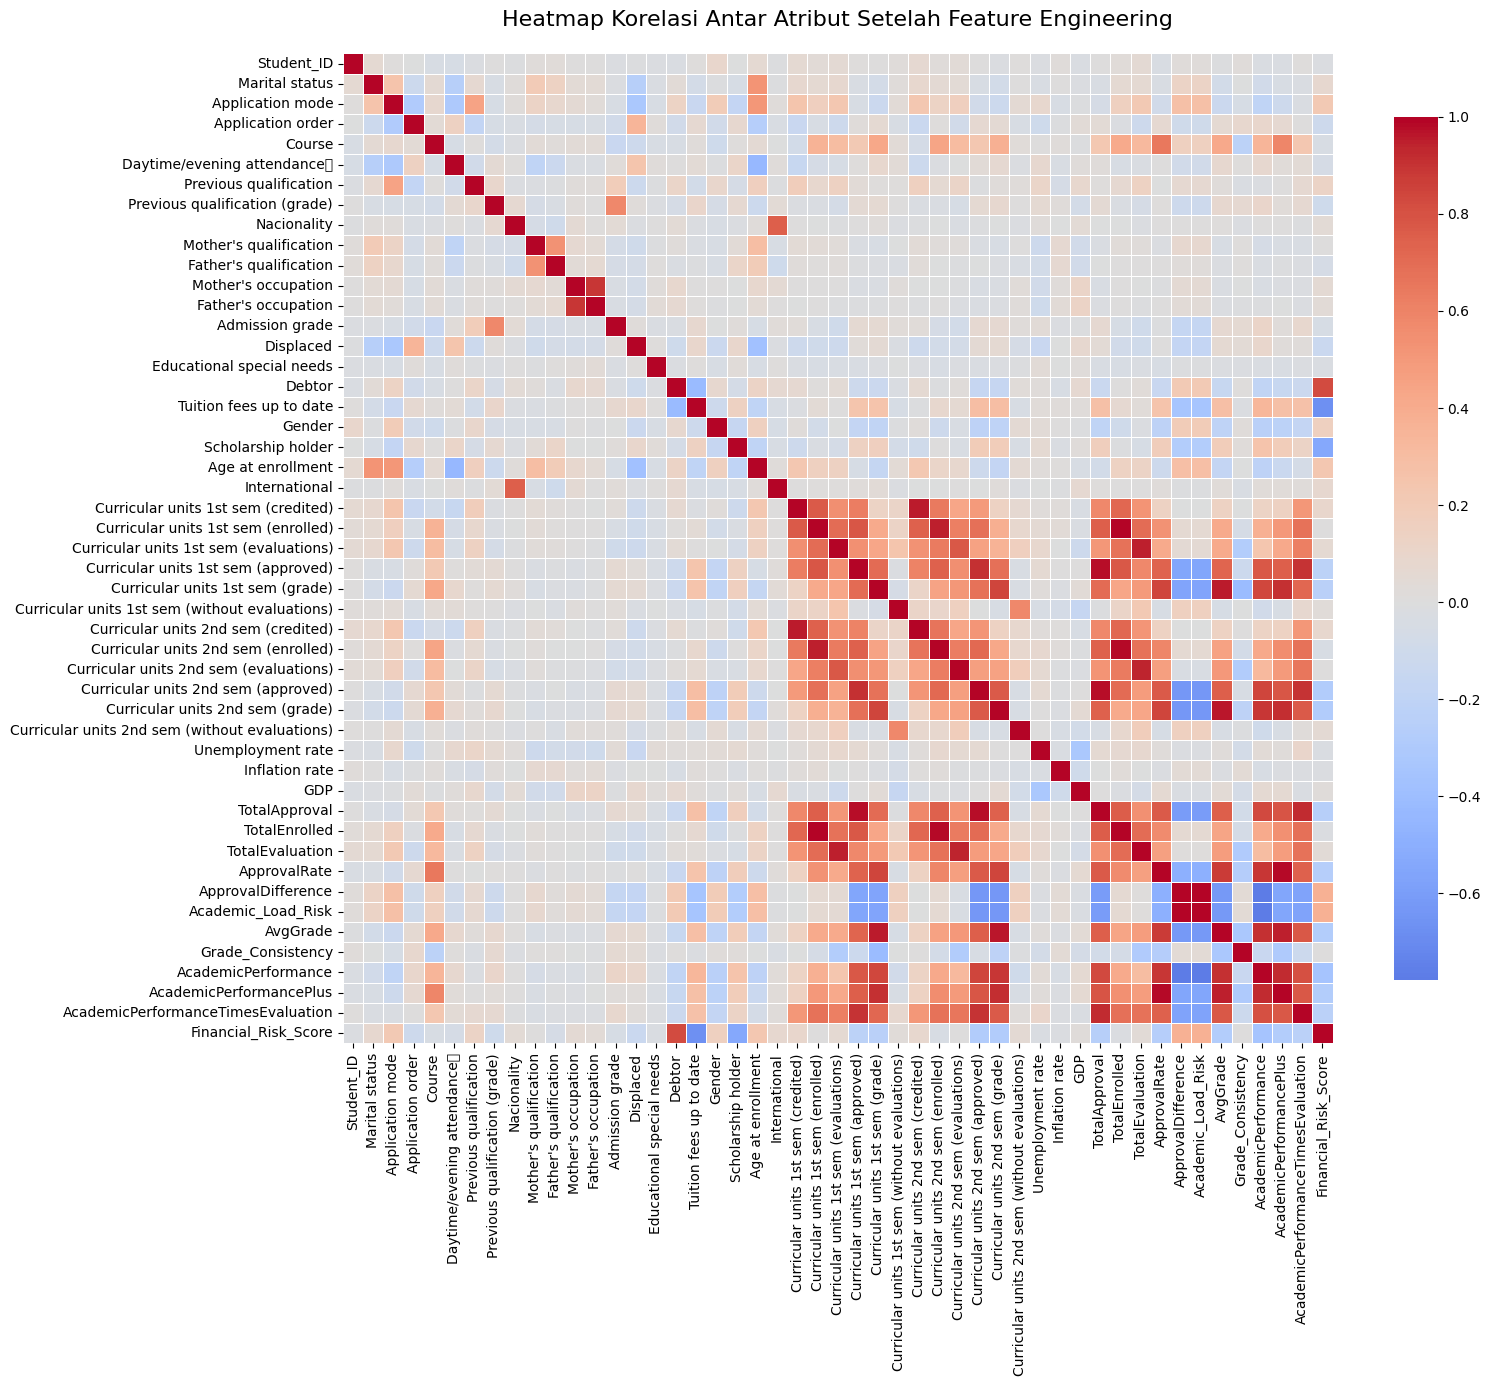

In [358]:
import matplotlib.pyplot as plt
import seaborn as sns

X_numeric = X_train_fe.select_dtypes(include=['int64', 'float64']).copy()
print(f"Numeric features shape: {X_numeric.shape}")
print(f"Numeric columns: {X_numeric.columns.tolist()[:10]}...")

correlation_matrix = X_numeric.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, square=True)
plt.title('Heatmap Korelasi Antar Atribut Setelah Feature Engineering', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**Explanation:** Feature engineering membuat 12 features baru yang lebih informatif, dikelompokkan berdasarkan kategori:

**Basic Features (3):**
- TotalApproval: Total unit yang disetujui dari kedua semester
- TotalEnrolled: Total unit yang didaftarkan dari kedua semester
- TotalEvaluation: Total evaluasi yang dilakukan

**Approval Metrics (3):**
- ApprovalRate: Rasio kelulusan untuk mengukur performa akademik (TotalApproval/TotalEnrolled)
- ApprovalDifference: Selisih enrolled dan approved untuk melihat unit yang tidak lulus
- Academic_Load_Risk: Jumlah unit yang gagal, indikator beban akademik yang berisiko

**Grade Metrics (2):**
- AvgGrade: Rata-rata nilai semester 1 dan 2
- Grade_Consistency: Konsistensi nilai antar semester (nilai lebih tinggi = lebih konsisten)

**Combined Performance (3):**
- AcademicPerformance: Kombinasi approval rate dengan normalized grade (perkalian)
- AcademicPerformancePlus: Alternatif perhitungan performa akademik (penjumlahan)
- AcademicPerformanceTimesEvaluation: Performa dikalikan jumlah evaluasi

**Financial Risk (1):**
- Financial_Risk_Score: Skor risiko finansial berdasarkan tunggakan, status debtor, dan beasiswa (nilai lebih tinggi = risiko lebih tinggi)

**Atribut to Drop**

In [359]:
ListColumnToDrop = [
    # ============================================================================
    # ORIGINAL SEMESTER COLUMNS (redundant after creating Total features)
    # ============================================================================
    # 'Curricular units 1st sem (approved)',
    # 'Curricular units 2nd sem (approved)',
    # 'Curricular units 1st sem (enrolled)',
    # 'Curricular units 2nd sem (enrolled)',
    # 'Curricular units 1st sem (evaluations)',
    # 'Curricular units 2nd sem (evaluations)',
    
    # ============================================================================
    # ENGINEERED FEATURES (FE1-FE12)
    # ============================================================================
    'TotalApproval',  # FE1
    'TotalEnrolled',  # FE2
    'TotalEvaluation',  # FE3
    'ApprovalRate',  # FE4
    # 'ApprovalDifference',  # FE5 - Same as Academic_Load_Risk
    # 'Academic_Load_Risk',  # FE6
    # 'AvgGrade',  # FE7
    # 'Grade_Consistency',  # FE8
    'AcademicPerformance',  # FE9
    'AcademicPerformancePlus',  # FE10 - Alternative version
    # 'AcademicPerformanceTimesEvaluation',  # FE11
    # 'Financial_Risk_Score',  # FE12
    
    # ============================================================================
    # CATEGORICAL COLUMNS (uncomment if not useful)
    # ============================================================================
    'Marital status',
    # 'Application mode',
    # 'Application order',
    # 'Course',
    # 'Previous qualification',
    # 'Nationality',
    "Mother's qualification",
    "Father's qualification",
    # "Mother's occupation",
    # "Father's occupation",
    # 'Educational special needs',
    'International',
    # 'Debtor',
    # 'Tuition fees up to date',
    # 'Scholarship holder',
    # 'Displaced',
    # 'Gender',
    
    # ============================================================================
    # CONTINUOUS COLUMNS (uncomment if not useful)
    # ============================================================================
    # 'Previous qualification (grade)',
    # 'Admission grade',
    # 'Age at enrollment',
    # 'Curricular units 1st sem (credited)',
    # 'Curricular units 1st sem (grade)',
    # 'Curricular units 1st sem (without evaluations)',
    # 'Curricular units 2nd sem (credited)',
    # 'Curricular units 2nd sem (grade)',
    # 'Curricular units 2nd sem (without evaluations)',
    # 'Unemployment rate',
    'Inflation rate'
    # 'GDP',
]

print(f"Columns to drop: {len(ListColumnToDrop)}")
print(f"Columns: {ListColumnToDrop}")

if len(ListColumnToDrop) > 0:
    X_train_fe = X_train_fe.drop(columns=ListColumnToDrop)
    X_val_fe = X_val_fe.drop(columns=ListColumnToDrop)
    print(f"\nAfter dropping columns:")
    print(f"Training shape: {X_train_fe.shape}")
    print(f"Validation shape: {X_val_fe.shape}")
else:
    print("\nNo columns to drop (all commented out)")

Columns to drop: 11
Columns: ['TotalApproval', 'TotalEnrolled', 'TotalEvaluation', 'ApprovalRate', 'AcademicPerformance', 'AcademicPerformancePlus', 'Marital status', "Mother's qualification", "Father's qualification", 'International', 'Inflation rate']

After dropping columns:
Training shape: (2476, 38)
Validation shape: (620, 38)


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [360]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [361]:
print("Skipping feature scaling for Decision Tree model")

Skipping feature scaling for Decision Tree model


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [362]:
existing_cat_cols = [col for col in categorical_cols if col in X_train_fe.columns]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train_fe[existing_cat_cols])
X_val_encoded = encoder.transform(X_val_fe[existing_cat_cols])

encoded_feature_names = encoder.get_feature_names_out(existing_cat_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train_fe.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_feature_names, index=X_val_fe.index)

X_train_final = X_train_fe.drop(columns=existing_cat_cols).join(X_train_encoded_df)
X_val_final = X_val_fe.drop(columns=existing_cat_cols).join(X_val_encoded_df)

print(f"Encoding completed")
print(f"Training shape after encoding: {X_train_final.shape}")
print(f"Validation shape after encoding: {X_val_final.shape}")

Encoding completed
Training shape after encoding: (2476, 165)
Validation shape after encoding: (620, 165)


**Explanation:** One-Hot Encoding digunakan untuk categorical features karena tidak ada urutan/hierarki antar kategori. Setiap kategori direpresentasikan sebagai binary column terpisah.

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [363]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_array))

print(f"Class weights computed:")
for cls, weight in class_weights.items():
    print(f"  {cls}: {weight:.4f}")

Class weights computed:
  Dropout: 1.0382
  Enrolled: 1.8547
  Graduate: 0.6677


**Explanation:** Class weights dihitung untuk menangani imbalanced dataset. Kelas minority akan diberi weight lebih besar sehingga model tidak bias ke kelas majority.

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [364]:
print("Skipping data normalization")

Skipping data normalization


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [365]:
print("Skipping dimensionality reduction")

Skipping dimensionality reduction


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [366]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [367]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [368]:
print("Preprocessing pipeline completed")
print(f"Final training set shape: {X_train_final.shape}")
print(f"Final validation set shape: {X_val_final.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Validation target shape: {y_val.shape}")
print(f"\nReady for modeling")

Preprocessing pipeline completed
Final training set shape: (2476, 165)
Final validation set shape: (620, 165)
Training target shape: (2476,)
Validation target shape: (620,)

Ready for modeling


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [369]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, gain=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.gain = gain
    
    def is_leaf(self):
        return self.value is not None

In [370]:
class DecisionTreeC45:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.class_weight = class_weight
        self.root = None
        self.feature_names = None
        self.n_features = None
        
    def entropy(self, y):
        classes, counts = np.unique(y, return_counts=True)
        
        if self.class_weight is not None:
            weighted_counts = np.array([counts[i] * self.class_weight.get(classes[i], 1.0) 
                                       for i in range(len(classes))])
            probabilities = weighted_counts / weighted_counts.sum()
        else:
            probabilities = counts / counts.sum()
        
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    
    def split_info(self, y_left, y_right, y):
        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
        
        split_info = -(n_left/n) * np.log2(n_left/n) - (n_right/n) * np.log2(n_right/n)
        return split_info
    
    def information_gain(self, y, y_left, y_right):
        parent_entropy = self.entropy(y)
        n = len(y)
        n_left, n_right = len(y_left), len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
        
        child_entropy = (n_left / n) * self.entropy(y_left) + (n_right / n) * self.entropy(y_right)
        ig = parent_entropy - child_entropy
        return ig
    
    def gain_ratio(self, y, y_left, y_right):
        ig = self.information_gain(y, y_left, y_right)
        si = self.split_info(y_left, y_right, y)
        
        if si == 0:
            return 0
        
        return ig / si
    
    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                gain = self.gain_ratio(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        if depth >= self.max_depth or n_classes == 1 or n_samples < self.min_samples_split:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)
        
        best_feature, best_threshold, best_gain = self.best_split(X, y)
        
        if best_feature is None:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)
        
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        left_child = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, 
                   left=left_child, right=right_child, gain=best_gain)
    
    def most_common_label(self, y):
        if self.class_weight is not None:
            classes, counts = np.unique(y, return_counts=True)
            weighted_counts = np.array([counts[i] * self.class_weight.get(classes[i], 1.0) 
                                       for i in range(len(classes))])
            return classes[np.argmax(weighted_counts)]
        else:
            return np.bincount(y).argmax()
    
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values
        else:
            self.feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        
        self.n_features = X.shape[1]
        self.root = self.build_tree(X, y)
        return self
    
    def predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self.predict_sample(x, self.root) for x in X])
    
    def print_tree(self, node=None, depth=0, prefix="Root"):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            print(f"{'  ' * depth}{prefix}: Leaf [Class={node.value}]")
        else:
            feature_name = self.feature_names[node.feature] if self.feature_names else f"X[{node.feature}]"
            print(f"{'  ' * depth}{prefix}: {feature_name} <= {node.threshold:.4f} (Gain Ratio: {node.gain:.4f})")
            
            if node.left:
                self.print_tree(node.left, depth + 1, "Left")
            if node.right:
                self.print_tree(node.right, depth + 1, "Right")
    
    def get_depth(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 0
        
        left_depth = self.get_depth(node.left) if node.left else 0
        right_depth = self.get_depth(node.right) if node.right else 0
        
        return 1 + max(left_depth, right_depth)
    
    def count_nodes(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        left_count = self.count_nodes(node.left) if node.left else 0
        right_count = self.count_nodes(node.right) if node.right else 0
        
        return 1 + left_count + right_count
    
    def count_leaves(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        left_leaves = self.count_leaves(node.left) if node.left else 0
        right_leaves = self.count_leaves(node.right) if node.right else 0
        
        return left_leaves + right_leaves

print("DecisionTreeC45 class created successfully")

DecisionTreeC45 class created successfully


In [371]:
dt_model = DecisionTreeC45(max_depth=10, min_samples_split=5, min_samples_leaf=2, class_weight=class_weights)
dt_model.fit(X_train_final, y_train)

print("Decision Tree Training Completed")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Total Nodes: {dt_model.count_nodes()}")
print(f"Leaf Nodes: {dt_model.count_leaves()}")

y_train_pred = dt_model.predict(X_train_final)
y_val_pred = dt_model.predict(X_val_final)

train_accuracy = np.mean(y_train_pred == y_train)
val_accuracy = np.mean(y_val_pred == y_val)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Decision Tree Training Completed
Tree Depth: 10
Total Nodes: 103
Leaf Nodes: 52

Training Accuracy: 0.7758
Validation Accuracy: 0.7435


In [372]:
print("="*80)
print("DECISION TREE STRUCTURE (First 20 levels)")
print("="*80)
dt_model.print_tree()
print("="*80)

DECISION TREE STRUCTURE (First 20 levels)
Root: ApprovalDifference <= 5.0000 (Gain Ratio: 0.3443)
  Left: Financial_Risk_Score <= 2.0000 (Gain Ratio: 0.2533)
    Left: ApprovalDifference <= 2.0000 (Gain Ratio: 0.2000)
      Left: Tuition fees up to date_0 <= 0.0000 (Gain Ratio: 0.1705)
        Left: Curricular units 2nd sem (grade) <= 10.6000 (Gain Ratio: 0.1334)
          Left: Admission grade <= 105.5000 (Gain Ratio: 0.2565)
            Left: Leaf [Class=Dropout]
            Right: Admission grade <= 176.0000 (Gain Ratio: 0.2338)
              Left: Admission grade <= 165.7000 (Gain Ratio: 0.2459)
                Left: Previous qualification_19 <= 0.0000 (Gain Ratio: 0.2404)
                  Left: Student_ID <= 4309.0000 (Gain Ratio: 0.2294)
                    Left: Leaf [Class=Enrolled]
                    Right: Leaf [Class=Graduate]
                  Right: Leaf [Class=Dropout]
                Right: Leaf [Class=Graduate]
              Right: Leaf [Class=Dropout]
          Right

In [373]:
from sklearn.metrics import confusion_matrix, classification_report

print("TRAINING SET PERFORMANCE")
print("="*80)
cm_train = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:")
print(cm_train)
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

print("\nVALIDATION SET PERFORMANCE")
print("="*80)
cm_val = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm_val)
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

TRAINING SET PERFORMANCE
Confusion Matrix:
[[ 603  121   71]
 [  62  224  159]
 [   8  134 1094]]

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.90      0.76      0.82       795
    Enrolled       0.47      0.50      0.48       445
    Graduate       0.83      0.89      0.85      1236

    accuracy                           0.78      2476
   macro avg       0.73      0.72      0.72      2476
weighted avg       0.78      0.78      0.78      2476


VALIDATION SET PERFORMANCE
Confusion Matrix:
[[146  28  25]
 [ 23  42  46]
 [  6  31 273]]

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.78       199
    Enrolled       0.42      0.38      0.40       111
    Graduate       0.79      0.88      0.83       310

    accuracy                           0.74       620
   macro avg       0.68      0.66      0.67       620
weighted avg       0.74      0.74      0.74       620



In [374]:
# Type your code here

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [375]:
from sklearn.metrics import f1_score

def calculate_f1_per_class(y_true, y_pred):
    classes = np.unique(y_true)
    f1_scores = {}
    
    for cls in classes:
        y_true_binary = (y_true == cls).astype(int)
        y_pred_binary = (y_pred == cls).astype(int)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        f1_scores[cls] = f1
    
    return f1_scores

print("F1 SCORE PER CLASS")
print("="*80)

print("\nTraining Set:")
f1_train = calculate_f1_per_class(y_train.values, y_train_pred)
for cls, score in f1_train.items():
    print(f"  Class {cls}: {score:.4f}")

print("\nValidation Set:")
f1_val = calculate_f1_per_class(y_val.values, y_val_pred)
for cls, score in f1_val.items():
    print(f"  Class {cls}: {score:.4f}")

macro_f1_train = np.mean(list(f1_train.values()))
macro_f1_val = np.mean(list(f1_val.values()))

print(f"\nMacro F1 Score (Training): {macro_f1_train:.4f}")
print(f"Macro F1 Score (Validation): {macro_f1_val:.4f}")

F1 SCORE PER CLASS

Training Set:
  Class Dropout: 0.8215
  Class Enrolled: 0.4848
  Class Graduate: 0.8547

Validation Set:
  Class Dropout: 0.7807
  Class Enrolled: 0.3962
  Class Graduate: 0.8349

Macro F1 Score (Training): 0.7204
Macro F1 Score (Validation): 0.6706


In [377]:
print("DEPTH EXPLORATION")
print("="*80)

depth_range = range(4, 7)
results = []

for depth in depth_range:
    model = DecisionTreeC45(max_depth=depth, min_samples_split=5, min_samples_leaf=2, class_weight=class_weights)
    model.fit(X_train_final, y_train)
    
    y_train_pred_temp = model.predict(X_train_final)
    y_val_pred_temp = model.predict(X_val_final)
    
    train_acc = np.mean(y_train_pred_temp == y_train)
    val_acc = np.mean(y_val_pred_temp == y_val)
    
    train_f1 = f1_score(y_train, y_train_pred_temp, average='macro')
    val_f1 = f1_score(y_val, y_val_pred_temp, average='macro')
    
    n_nodes = model.count_nodes()
    n_leaves = model.count_leaves()
    
    results.append({
        'depth': depth,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'nodes': n_nodes,
        'leaves': n_leaves
    })
    
    print(f"Depth {depth:2d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Nodes: {n_nodes:4d}")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("BEST MODELS BY VALIDATION ACCURACY")
print("="*80)
best_by_acc = results_df.loc[results_df['val_acc'].idxmax()]
print(f"Best Depth: {int(best_by_acc['depth'])}")
print(f"Validation Accuracy: {best_by_acc['val_acc']:.4f}")
print(f"Validation F1: {best_by_acc['val_f1']:.4f}")

print("\n" + "="*80)
print("BEST MODELS BY VALIDATION F1 SCORE")
print("="*80)
best_by_f1 = results_df.loc[results_df['val_f1'].idxmax()]
print(f"Best Depth: {int(best_by_f1['depth'])}")
print(f"Validation Accuracy: {best_by_f1['val_acc']:.4f}")
print(f"Validation F1: {best_by_f1['val_f1']:.4f}")

DEPTH EXPLORATION
Depth  4 | Train Acc: 0.7548 | Val Acc: 0.7419 | Train F1: 0.6815 | Val F1: 0.6585 | Nodes:   21
Depth  4 | Train Acc: 0.7548 | Val Acc: 0.7419 | Train F1: 0.6815 | Val F1: 0.6585 | Nodes:   21
Depth  5 | Train Acc: 0.7476 | Val Acc: 0.7387 | Train F1: 0.6892 | Val F1: 0.6662 | Nodes:   31
Depth  5 | Train Acc: 0.7476 | Val Acc: 0.7387 | Train F1: 0.6892 | Val F1: 0.6662 | Nodes:   31
Depth  6 | Train Acc: 0.7553 | Val Acc: 0.7403 | Train F1: 0.6967 | Val F1: 0.6677 | Nodes:   47

BEST MODELS BY VALIDATION ACCURACY
Best Depth: 4
Validation Accuracy: 0.7419
Validation F1: 0.6585

BEST MODELS BY VALIDATION F1 SCORE
Best Depth: 6
Validation Accuracy: 0.7403
Validation F1: 0.6677
Depth  6 | Train Acc: 0.7553 | Val Acc: 0.7403 | Train F1: 0.6967 | Val F1: 0.6677 | Nodes:   47

BEST MODELS BY VALIDATION ACCURACY
Best Depth: 4
Validation Accuracy: 0.7419
Validation F1: 0.6585

BEST MODELS BY VALIDATION F1 SCORE
Best Depth: 6
Validation Accuracy: 0.7403
Validation F1: 0.6677


**FINE-Tuning Hyperparameters**

In [378]:
print("SIMPLE HYPERPARAMETER TUNING")
print("="*80)
print("Testing key hyperparameter combinations to optimize performance")
print("="*80)

# Define simplified hyperparameter grid (fewer combinations for faster training)
max_depth_range = [5, 6, 7]
min_samples_split_range = [5, 10, 15]
min_samples_leaf_range = [2, 4]

tuning_results = []
best_val_f1 = -1
best_params = None

total_combinations = len(max_depth_range) * len(min_samples_split_range) * len(min_samples_leaf_range)
print(f"Testing {total_combinations} hyperparameter combinations...\n")

# Grid search over hyperparameters
for max_depth in max_depth_range:
    for min_samples_split in min_samples_split_range:
        for min_samples_leaf in min_samples_leaf_range:
            # Skip invalid combinations
            if min_samples_split < 2 * min_samples_leaf:
                continue
            
            # Train model
            model = DecisionTreeC45(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weights
            )
            model.fit(X_train_final, y_train)
            
            # Predictions
            y_train_pred_temp = model.predict(X_train_final)
            y_val_pred_temp = model.predict(X_val_final)
            
            # Metrics
            train_acc = np.mean(y_train_pred_temp == y_train)
            val_acc = np.mean(y_val_pred_temp == y_val)
            train_f1 = f1_score(y_train, y_train_pred_temp, average='macro')
            val_f1 = f1_score(y_val, y_val_pred_temp, average='macro')
            overfit_gap = train_f1 - val_f1
            
            # Store results
            result = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'train_f1': train_f1,
                'val_f1': val_f1,
                'overfit_gap': overfit_gap,
                'nodes': model.count_nodes()
            }
            tuning_results.append(result)
            
            # Track best model
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf
                }
            
            print(f"Depth={max_depth}, Split={min_samples_split:2d}, Leaf={min_samples_leaf} | "
                  f"Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}, Overfit Gap={overfit_gap:.4f}")

print(f"\n{'='*80}")
print("TUNING RESULTS:")
print("="*80)

# Convert to DataFrame
tuning_df = pd.DataFrame(tuning_results)
tuning_df_sorted = tuning_df.sort_values('val_f1', ascending=False)

print("\nTOP 5 MODELS:")
print(tuning_df_sorted[['max_depth', 'min_samples_split', 'min_samples_leaf', 
                         'val_acc', 'val_f1', 'overfit_gap']].head(5).to_string(index=False))

print(f"\n{'='*80}")
print("BEST MODEL:")
print("="*80)
print(f"Max Depth: {best_params['max_depth']}")
print(f"Min Samples Split: {best_params['min_samples_split']}")
print(f"Min Samples Leaf: {best_params['min_samples_leaf']}")
print(f"\nValidation F1: {best_val_f1:.4f}")
print(f"Validation Accuracy: {tuning_df_sorted.iloc[0]['val_acc']:.4f}")
print(f"Overfitting Gap: {tuning_df_sorted.iloc[0]['overfit_gap']:.4f}")

# Find best balanced model (low overfitting + high performance)
tuning_df['balance_score'] = tuning_df['val_f1'] - (0.5 * tuning_df['overfit_gap'])
best_balanced = tuning_df.sort_values('balance_score', ascending=False).iloc[0]

print(f"\n{'='*80}")
print("BEST BALANCED MODEL (Low Overfitting + High Performance):")
print("="*80)
print(f"Max Depth: {int(best_balanced['max_depth'])}")
print(f"Min Samples Split: {int(best_balanced['min_samples_split'])}")
print(f"Min Samples Leaf: {int(best_balanced['min_samples_leaf'])}")
print(f"Validation F1: {best_balanced['val_f1']:.4f}")
print(f"Overfitting Gap: {best_balanced['overfit_gap']:.4f}")

# Train final tuned model with best params
print(f"\n{'='*80}")
print("TRAINING FINAL TUNED MODEL...")
print("="*80)

best_tuned_model = DecisionTreeC45(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    class_weight=class_weights
)
best_tuned_model.fit(X_train_final, y_train)

print(f"Model trained with best hyperparameters!")
print(f"Tree Depth: {best_tuned_model.get_depth()}")
print(f"Total Nodes: {best_tuned_model.count_nodes()}")

COMPREHENSIVE HYPERPARAMETER TUNING
Exploring multiple hyperparameters to reduce overfitting/underfitting

Testing 80 hyperparameter combinations...
This may take a few minutes...

Progress: 80/80 combinations tested...

Hyperparameter tuning completed!

TOP 10 MODELS BY VALIDATION F1 SCORE:
 max_depth  min_samples_split  min_samples_leaf  val_acc   val_f1  overfit_gap  nodes
         8                 20                 6 0.750000 0.683091     0.032416     63
         7                 20                 6 0.750000 0.683091     0.028972     51
         6                 20                 8 0.753226 0.682659     0.025242     45
         6                 20                 6 0.750000 0.680445     0.025846     41
         5                 10                 4 0.751613 0.679981     0.014968     35
         7                 20                 8 0.758065 0.679474     0.037061     57
         8                 15                 6 0.745161 0.678311     0.038854     69
         7         

**Visualisasi Fine-Tuning Results**

Visualization saved to '../submission/hyperparameter_tuning_visualization.png'


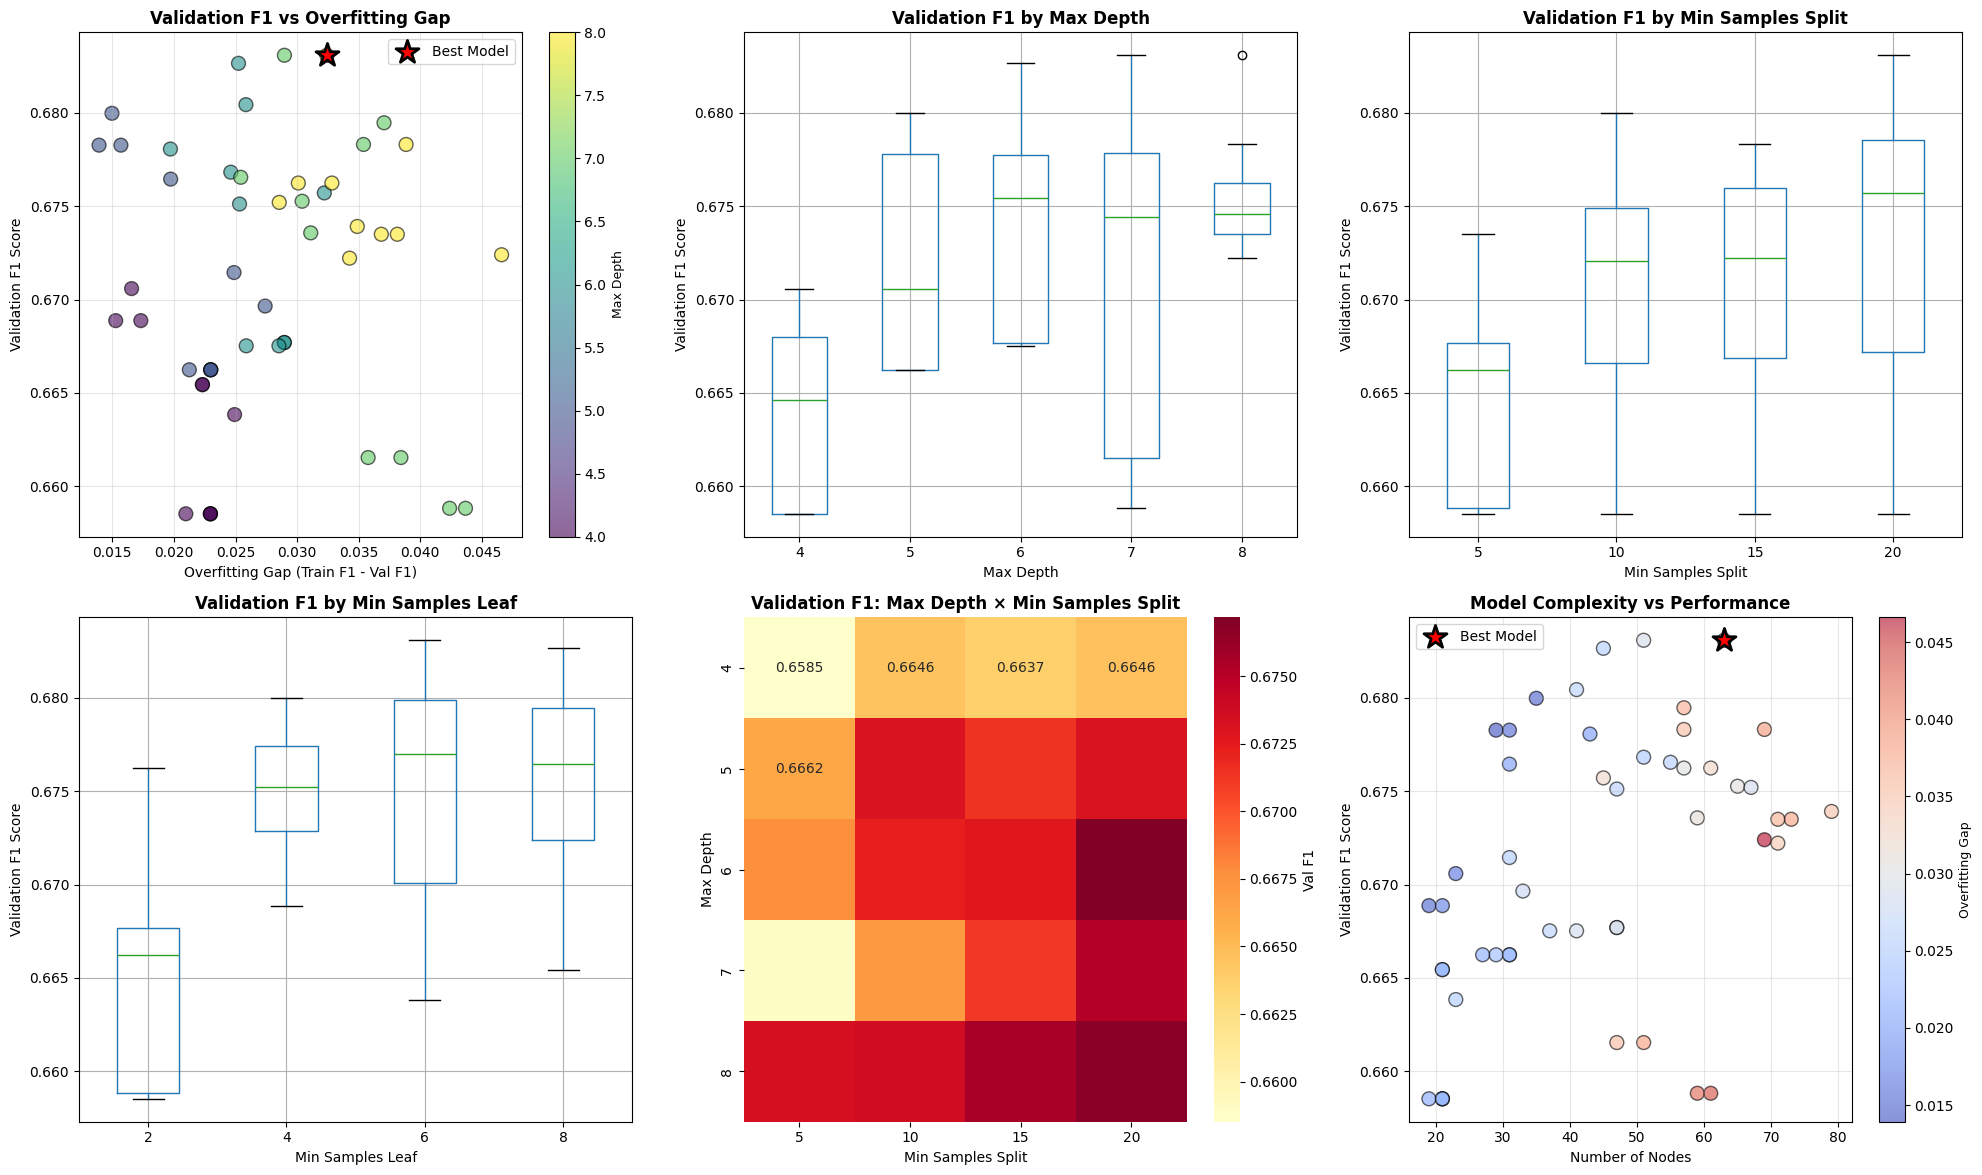


HYPERPARAMETER IMPACT ANALYSIS:

Impact of Max Depth:
             mean     std     min     max
max_depth                                
4          0.6637  0.0049  0.6585  0.6706
5          0.6719  0.0058  0.6662  0.6800
6          0.6739  0.0059  0.6675  0.6827
7          0.6707  0.0094  0.6588  0.6831
8          0.6755  0.0033  0.6722  0.6831

Impact of Min Samples Split:
                     mean     std     min     max
min_samples_split                                
5                  0.6650  0.0064  0.6585  0.6735
10                 0.6701  0.0073  0.6585  0.6800
15                 0.6709  0.0064  0.6585  0.6783
20                 0.6733  0.0074  0.6585  0.6831

Impact of Min Samples Leaf:
                    mean     std     min     max
min_samples_leaf                                
2                 0.6655  0.0060  0.6585  0.6762
4                 0.6748  0.0034  0.6689  0.6800
6                 0.6749  0.0070  0.6638  0.6831
8                 0.6753  0.0067  0.6654  0.682

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(20, 12))

# 1. Validation F1 vs Overfitting Gap (scatter plot)
ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(tuning_df['overfit_gap'], tuning_df['val_f1'], 
                     c=tuning_df['max_depth'], cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black')
ax1.set_xlabel('Overfitting Gap (Train F1 - Val F1)', fontsize=10)
ax1.set_ylabel('Validation F1 Score', fontsize=10)
ax1.set_title('Validation F1 vs Overfitting Gap', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Max Depth', fontsize=9)

# Mark best model
best_row = tuning_df_sorted.iloc[0]
ax1.scatter(best_row['overfit_gap'], best_row['val_f1'], 
           color='red', s=300, marker='*', edgecolors='black', linewidths=2,
           label='Best Model', zorder=5)
ax1.legend()

# 2. Max Depth vs Validation F1 (box plot)
ax2 = plt.subplot(2, 3, 2)
tuning_df.boxplot(column='val_f1', by='max_depth', ax=ax2)
ax2.set_xlabel('Max Depth', fontsize=10)
ax2.set_ylabel('Validation F1 Score', fontsize=10)
ax2.set_title('Validation F1 by Max Depth', fontsize=12, fontweight='bold')
plt.sca(ax2)
plt.xticks(rotation=0)
ax2.get_figure().suptitle('')  # Remove auto-generated title

# 3. Min Samples Split vs Validation F1 (box plot)
ax3 = plt.subplot(2, 3, 3)
tuning_df.boxplot(column='val_f1', by='min_samples_split', ax=ax3)
ax3.set_xlabel('Min Samples Split', fontsize=10)
ax3.set_ylabel('Validation F1 Score', fontsize=10)
ax3.set_title('Validation F1 by Min Samples Split', fontsize=12, fontweight='bold')
plt.sca(ax3)
plt.xticks(rotation=0)
ax3.get_figure().suptitle('')

# 4. Min Samples Leaf vs Validation F1 (box plot)
ax4 = plt.subplot(2, 3, 4)
tuning_df.boxplot(column='val_f1', by='min_samples_leaf', ax=ax4)
ax4.set_xlabel('Min Samples Leaf', fontsize=10)
ax4.set_ylabel('Validation F1 Score', fontsize=10)
ax4.set_title('Validation F1 by Min Samples Leaf', fontsize=12, fontweight='bold')
plt.sca(ax4)
plt.xticks(rotation=0)
ax4.get_figure().suptitle('')

# 5. Heatmap: Max Depth vs Min Samples Split (average Val F1)
ax5 = plt.subplot(2, 3, 5)
pivot_table = tuning_df.pivot_table(
    values='val_f1', 
    index='max_depth', 
    columns='min_samples_split', 
    aggfunc='mean'
)
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax5, cbar_kws={'label': 'Val F1'})
ax5.set_xlabel('Min Samples Split', fontsize=10)
ax5.set_ylabel('Max Depth', fontsize=10)
ax5.set_title('Validation F1: Max Depth × Min Samples Split', fontsize=12, fontweight='bold')

# 6. Model Complexity (nodes) vs Performance
ax6 = plt.subplot(2, 3, 6)
scatter2 = ax6.scatter(tuning_df['nodes'], tuning_df['val_f1'], 
                      c=tuning_df['overfit_gap'], cmap='coolwarm',
                      s=100, alpha=0.6, edgecolors='black')
ax6.set_xlabel('Number of Nodes', fontsize=10)
ax6.set_ylabel('Validation F1 Score', fontsize=10)
ax6.set_title('Model Complexity vs Performance', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax6)
cbar2.set_label('Overfitting Gap', fontsize=9)

# Mark best model
ax6.scatter(best_row['nodes'], best_row['val_f1'], 
           color='red', s=300, marker='*', edgecolors='black', linewidths=2,
           label='Best Model', zorder=5)
ax6.legend()

plt.tight_layout()
plt.savefig('../submission/hyperparameter_tuning_visualization.png', dpi=300, bbox_inches='tight')
print("Visualization saved to '../submission/hyperparameter_tuning_visualization.png'")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("HYPERPARAMETER IMPACT ANALYSIS:")
print("="*80)

print("\nImpact of Max Depth:")
print(tuning_df.groupby('max_depth')['val_f1'].agg(['mean', 'std', 'min', 'max']).round(4))

print("\nImpact of Min Samples Split:")
print(tuning_df.groupby('min_samples_split')['val_f1'].agg(['mean', 'std', 'min', 'max']).round(4))

print("\nImpact of Min Samples Leaf:")
print(tuning_df.groupby('min_samples_leaf')['val_f1'].agg(['mean', 'std', 'min', 'max']).round(4))

**Visual Depth**

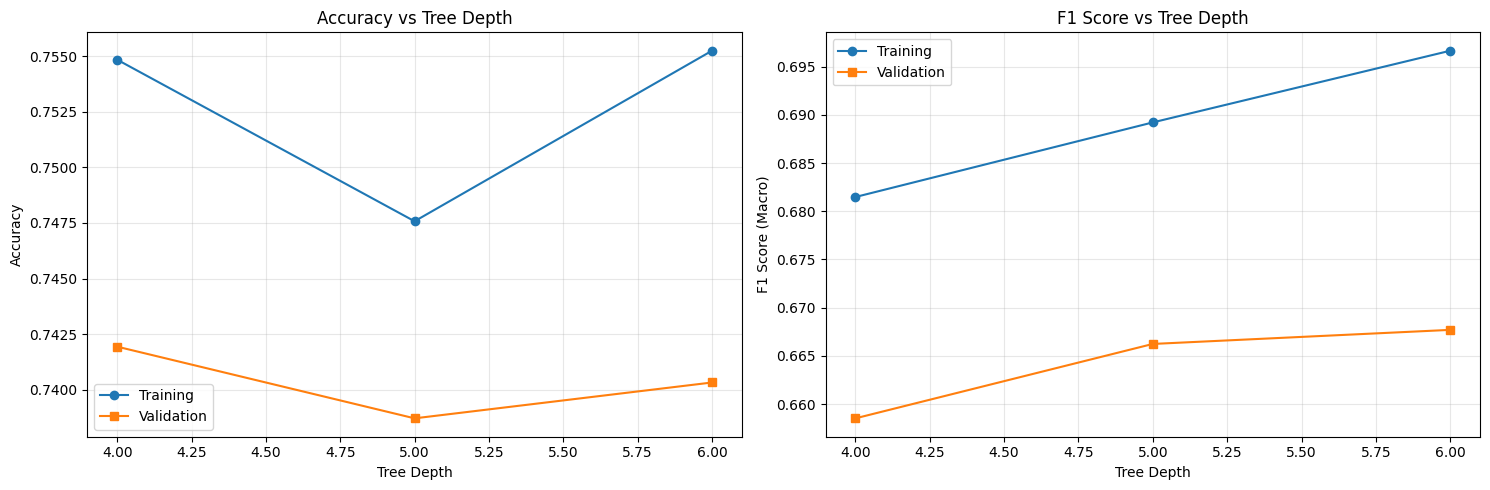

In [380]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(results_df['depth'], results_df['train_acc'], label='Training', marker='o')
axes[0].plot(results_df['depth'], results_df['val_acc'], label='Validation', marker='s')
axes[0].set_xlabel('Tree Depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Tree Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['depth'], results_df['train_f1'], label='Training', marker='o')
axes[1].plot(results_df['depth'], results_df['val_f1'], label='Validation', marker='s')
axes[1].set_xlabel('Tree Depth')
axes[1].set_ylabel('F1 Score (Macro)')
axes[1].set_title('F1 Score vs Tree Depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [381]:
print("TRAINING BEST MODEL")
print("="*80)

best_depth = int(best_by_f1['depth'])
print(f"Using best depth: {best_depth}")

best_model = DecisionTreeC45(max_depth=best_depth, min_samples_split=5, min_samples_leaf=2, class_weight=class_weights)
best_model.fit(X_train_final, y_train)

y_train_pred_best = best_model.predict(X_train_final)
y_val_pred_best = best_model.predict(X_val_final)

train_acc_best = np.mean(y_train_pred_best == y_train)
val_acc_best = np.mean(y_val_pred_best == y_val)

print(f"\nBest Model Performance:")
print(f"Training Accuracy: {train_acc_best:.4f}")
print(f"Validation Accuracy: {val_acc_best:.4f}")
print(f"Tree Depth: {best_model.get_depth()}")
print(f"Total Nodes: {best_model.count_nodes()}")
print(f"Leaf Nodes: {best_model.count_leaves()}")

print("\n" + "="*80)
print("CONFUSION MATRIX - BEST MODEL")
print("="*80)
cm_val_best = confusion_matrix(y_val, y_val_pred_best)
print("Validation Set:")
print(cm_val_best)
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best))

print("\n" + "="*80)
print("BEST TREE STRUCTURE")
print("="*80)
best_model.print_tree()
print("="*80)

TRAINING BEST MODEL
Using best depth: 6

Best Model Performance:
Training Accuracy: 0.7553
Validation Accuracy: 0.7403
Tree Depth: 6
Total Nodes: 47
Leaf Nodes: 24

CONFUSION MATRIX - BEST MODEL
Validation Set:
[[142  32  25]
 [ 24  43  44]
 [  5  31 274]]

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       199
    Enrolled       0.41      0.39      0.40       111
    Graduate       0.80      0.88      0.84       310

    accuracy                           0.74       620
   macro avg       0.68      0.66      0.67       620
weighted avg       0.74      0.74      0.74       620


BEST TREE STRUCTURE
Root: ApprovalDifference <= 5.0000 (Gain Ratio: 0.3443)
  Left: Financial_Risk_Score <= 2.0000 (Gain Ratio: 0.2533)
    Left: ApprovalDifference <= 2.0000 (Gain Ratio: 0.2000)
      Left: Tuition fees up to date_0 <= 0.0000 (Gain Ratio: 0.1705)
        Left: Curricular units 2nd sem (grade) <= 10.6000 (Gain Ratio: 0

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [382]:
print("PREPROCESSING TEST DATA FOR SUBMISSION")
print("="*80)

test_df = pd.read_csv("../data/test.csv")
test_ids = test_df['Student_ID']
X_test = test_df.drop(columns=['Student_ID'])

print(f"Test data shape: {X_test.shape}")

existing_cat_cols = [col for col in categorical_cols if col in X_test.columns]
existing_cont_cols = [col for col in continuous_cols if col in X_test.columns]

if len(existing_cat_cols) > 0:
    X_test[existing_cat_cols] = imputer_cat.transform(X_test[existing_cat_cols])

if len(existing_cont_cols) > 0:
    X_test[existing_cont_cols] = imputer_num.transform(X_test[existing_cont_cols])

print("Missing values after imputation:", X_test.isnull().sum().sum())

PREPROCESSING TEST DATA FOR SUBMISSION
Test data shape: (1328, 36)
Missing values after imputation: 0


In [383]:
print("FEATURE ENGINEERING FOR TEST DATA")
print("="*80)

# ============================================================================
# BASIC FEATURES (Total Units)
# ============================================================================
X_test['TotalApproval'] = X_test['Curricular units 1st sem (approved)'] + X_test['Curricular units 2nd sem (approved)']
X_test['TotalEnrolled'] = X_test['Curricular units 1st sem (enrolled)'] + X_test['Curricular units 2nd sem (enrolled)']
X_test['TotalEvaluation'] = X_test['Curricular units 1st sem (evaluations)'] + X_test['Curricular units 2nd sem (evaluations)']

# ============================================================================
# APPROVAL METRICS
# ============================================================================
X_test['ApprovalRate'] = np.where(
    X_test['TotalEnrolled'] == 0,
    -1,
    X_test['TotalApproval'] / X_test['TotalEnrolled']
)
X_test['ApprovalDifference'] = X_test['TotalEnrolled'] - X_test['TotalApproval']
X_test['Academic_Load_Risk'] = X_test['TotalEnrolled'] - X_test['TotalApproval']

# ============================================================================
# GRADE METRICS
# ============================================================================
X_test['AvgGrade'] = (X_test['Curricular units 1st sem (grade)'] + X_test['Curricular units 2nd sem (grade)']) / 2

grade_variance_test = np.abs(X_test['Curricular units 1st sem (grade)'] - X_test['Curricular units 2nd sem (grade)'])
X_test['Grade_Consistency'] = np.where(
    grade_variance_test > 0,
    1 / (1 + grade_variance_test),
    1.0
)

# ============================================================================
# COMBINED ACADEMIC PERFORMANCE METRICS
# ============================================================================
max_avg_grade_test = X_test['AvgGrade'].max()
if max_avg_grade_test > 0:
    X_test['AcademicPerformance'] = X_test['ApprovalRate'] * (X_test['AvgGrade'] / max_avg_grade_test)
    X_test['AcademicPerformancePlus'] = X_test['ApprovalRate'] + (X_test['AvgGrade'] / max_avg_grade_test)
else:
    X_test['AcademicPerformance'] = 0
    X_test['AcademicPerformancePlus'] = 0

X_test['AcademicPerformanceTimesEvaluation'] = X_test['AcademicPerformance'] * X_test['TotalEvaluation']

# ============================================================================
# FINANCIAL RISK METRICS
# ============================================================================
X_test['Financial_Risk_Score'] = (
    (1 - X_test['Tuition fees up to date']) + 
    (2 * X_test['Debtor']) - 
    X_test['Scholarship holder']
)

print(f"Test data shape after feature engineering: {X_test.shape}")

# ============================================================================
# DROP SAME COLUMNS AS TRAINING DATA
# ============================================================================
print("\nDropping same columns as training data...")
test_cols_to_drop = [col for col in ListColumnToDrop if col in X_test.columns]
if len(test_cols_to_drop) > 0:
    X_test = X_test.drop(columns=test_cols_to_drop)
    print(f"Dropped {len(test_cols_to_drop)} columns from test data")
    print(f"Test data shape after dropping: {X_test.shape}")
else:
    print("No columns to drop")

FEATURE ENGINEERING FOR TEST DATA
Test data shape after feature engineering: (1328, 48)

Dropping same columns as training data...
Dropped 11 columns from test data
Test data shape after dropping: (1328, 37)


In [384]:
print("ENCODING TEST DATA")
print("="*80)

# Only encode categorical columns that exist in the training data after dropping
existing_cat_cols_test = [col for col in categorical_cols if col in X_test.columns and col in X_train_fe.columns]
print(f"Categorical columns to encode in test data: {len(existing_cat_cols_test)}")

X_test_encoded = encoder.transform(X_test[existing_cat_cols_test])
encoded_feature_names = encoder.get_feature_names_out(existing_cat_cols_test)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

X_test_final = X_test.drop(columns=existing_cat_cols_test).join(X_test_encoded_df)

print(f"Test data shape after encoding: {X_test_final.shape}")
print(f"Training data shape: {X_train_final.shape}")

missing_cols = set(X_train_final.columns) - set(X_test_final.columns)
if missing_cols:
    print(f"\nWarning: Missing columns in test data: {missing_cols}")
    for col in missing_cols:
        X_test_final[col] = 0

extra_cols = set(X_test_final.columns) - set(X_train_final.columns)
if extra_cols:
    print(f"\nWarning: Extra columns in test data: {extra_cols}")
    X_test_final = X_test_final.drop(columns=list(extra_cols))

X_test_final = X_test_final[X_train_final.columns]
print(f"\nFinal test data shape: {X_test_final.shape}")

ENCODING TEST DATA
Categorical columns to encode in test data: 12
Test data shape after encoding: (1328, 164)
Training data shape: (2476, 165)


Final test data shape: (1328, 165)


In [385]:
print("GENERATING PREDICTIONS")
print("="*80)

y_test_pred = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'Student_ID': test_ids,
    'Target': y_test_pred
})

import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
submission_path = f"../submission/submission_DTL_{timestamp}.csv"
submission.to_csv(submission_path, index=False)

print(f"Submission file created: {submission_path}")
print(f"Number of predictions: {len(submission)}")
print(f"\nPrediction distribution:")
print(submission['Target'].value_counts().sort_index())
print("="*80)

GENERATING PREDICTIONS
Submission file created: ../submission/submission_DTL_20251204_220153.csv
Number of predictions: 1328

Prediction distribution:
Target
Dropout     356
Enrolled    276
Graduate    696
Name: count, dtype: int64


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`